# MNIST: Klasyfikator Neuronowy i Autoencoder z 2D przestrzenią latentną

## Importy i konfiguracja

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Dla lepszej czytelności wykresów
plt.rcParams['figure.dpi'] = 100

---
## 1) Przygotowanie danych MNIST

Ładujemy zbiór MNIST i normalizujemy piksele do zakresu [0, 1]. Spłaszczamy obrazy 28×28 do wektorów 784-wymiarowych.


In [7]:
print("Ładowanie danych MNIST...")
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalizacja do [0, 1]
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Spłaszczenie obrazów 28x28 -> 784
x_train_flat = x_train.reshape(-1, 784)
x_test_flat = x_test.reshape(-1, 784)

print(f"Train: {x_train.shape}, Test: {x_test.shape}")
print(f"Train flat: {x_train_flat.shape}, Test flat: {x_test_flat.shape}")

Ładowanie danych MNIST...
Train: (60000, 28, 28), Test: (10000, 28, 28)
Train flat: (60000, 784), Test flat: (10000, 784)


###  Wizualizacja przykładowych cyfr

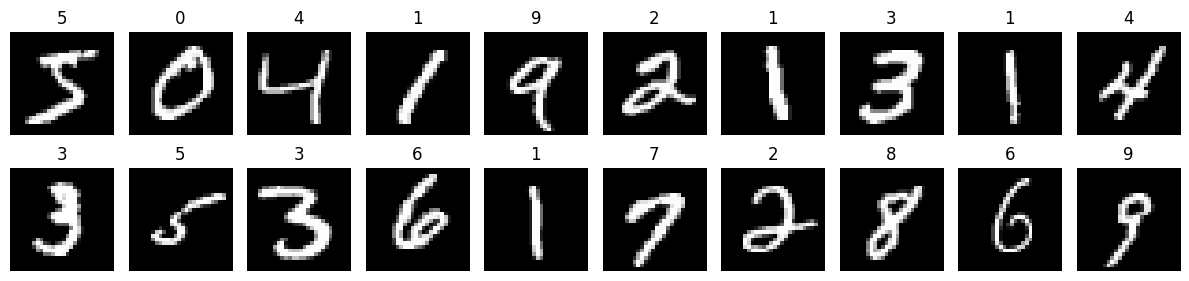

In [8]:
fig, axes = plt.subplots(2, 10, figsize=(12, 3))
for i in range(10):
    axes[0, i].imshow(x_train[i], cmap='gray')
    axes[0, i].set_title(f'{y_train[i]}')
    axes[0, i].axis('off')

    axes[1, i].imshow(x_train[i+10], cmap='gray')
    axes[1, i].set_title(f'{y_train[i+10]}')
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

---
## 2️) Klasyfikator neuronowy dla cyfr

Budujemy prosty klasyfikator z warstwami Dense. Będzie trenowany na **oryginalnych** obrazach.

In [9]:
print("=== BUDOWANIE KLASYFIKATORA ===")
classifier = models.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(10, activation='softmax')
])

classifier.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

classifier.summary()

=== BUDOWANIE KLASYFIKATORA ===
Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_43 (Dense)            (None, 128)               100480    
                                                                 
 dropout_5 (Dropout)         (None, 128)               0         
                                                                 
 dense_44 (Dense)            (None, 64)                8256      
                                                                 
 dropout_6 (Dropout)         (None, 64)                0         
                                                                 
 dense_45 (Dense)            (None, 10)                650       
                                                                 
Total params: 109,386
Trainable params: 109,386
Non-trainable params: 0
_________________________________________________________________


### Trening klasyfikatora

In [10]:
print("Trening klasyfikatora...")
history_classifier = classifier.fit(
    x_train_flat, y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

Trening klasyfikatora...
Epoch 1/10
422/422 [==============================] - 3s 6ms/step - loss: 0.4779 - accuracy: 0.8571 - val_loss: 0.1487 - val_accuracy: 0.9600
Epoch 2/10
422/422 [==============================] - 2s 6ms/step - loss: 0.2133 - accuracy: 0.9367 - val_loss: 0.1045 - val_accuracy: 0.9697
Epoch 3/10
422/422 [==============================] - 2s 5ms/step - loss: 0.1563 - accuracy: 0.9533 - val_loss: 0.0893 - val_accuracy: 0.9733
Epoch 4/10
422/422 [==============================] - 2s 5ms/step - loss: 0.1292 - accuracy: 0.9617 - val_loss: 0.0819 - val_accuracy: 0.9752
Epoch 5/10
422/422 [==============================] - 2s 5ms/step - loss: 0.1105 - accuracy: 0.9672 - val_loss: 0.0757 - val_accuracy: 0.9782
Epoch 6/10
422/422 [==============================] - 2s 5ms/step - loss: 0.0952 - accuracy: 0.9713 - val_loss: 0.0759 - val_accuracy: 0.9775
Epoch 7/10
422/422 [==============================] - 2s 5ms/step - loss: 0.0870 - accuracy: 0.9731 - val_loss: 0.0718 - va

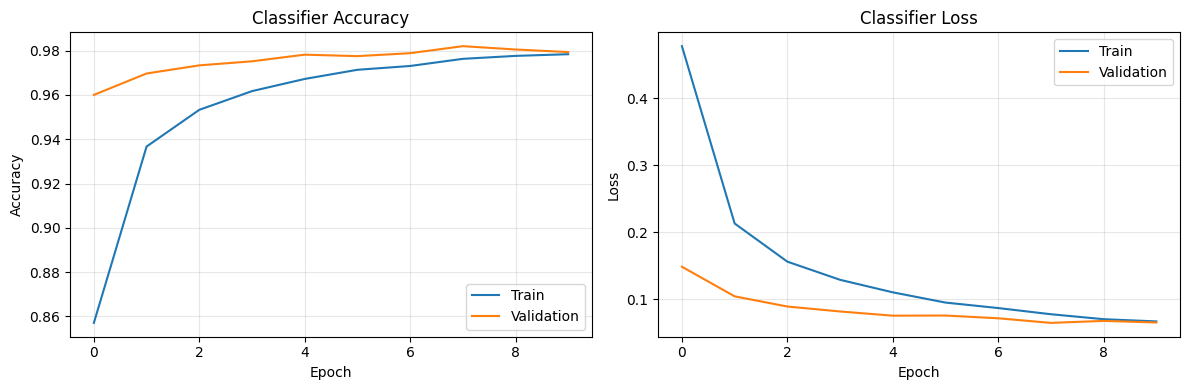

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Dokładność
axes[0].plot(history_classifier.history['accuracy'], label='Train')
axes[0].plot(history_classifier.history['val_accuracy'], label='Validation')
axes[0].set_title('Classifier Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(history_classifier.history['loss'], label='Train')
axes[1].plot(history_classifier.history['val_loss'], label='Validation')
axes[1].set_title('Classifier Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Ocena na obrazach oryginalnych

In [12]:
loss_orig, acc_orig = classifier.evaluate(x_test_flat, y_test, verbose=0)
print(f"Dokładność klasyfikatora na ORYGINALNYCH obrazach: {acc_orig:.4f}")

Dokładność klasyfikatora na ORYGINALNYCH obrazach: 0.9797


---
## 3️) Autoencoder z 2D przestrzenią latentną

Budujemy autoencoder, który kompresuje obrazy 784D → **2D** → 784D. Warstwa latentna używa **tanh**, aby wartości były w przedziale (-1, 1).

###  Architektura Encodera

In [13]:
print("=== BUDOWANIE AUTOENCODERA ===")

# Encoder: 784 -> 512 -> 256 -> 128 -> 64 -> 2
encoder_input = layers.Input(shape=(784,))
x = layers.Dense(512, activation='relu')(encoder_input)
x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(64, activation='relu')(x)
latent = layers.Dense(2, activation='tanh', name='latent')(x)  # tanh -> (-1, 1)

encoder = models.Model(encoder_input, latent, name='encoder')
encoder.summary()

=== BUDOWANIE AUTOENCODERA ===
Model: "encoder"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_18 (InputLayer)       [(None, 784)]             0         
                                                                 
 dense_46 (Dense)            (None, 512)               401920    
                                                                 
 batch_normalization_7 (Batc  (None, 512)              2048      
 hNormalization)                                                 
                                                                 
 dense_47 (Dense)            (None, 256)               131328    
                                                                 
 batch_normalization_8 (Batc  (None, 256)              1024      
 hNormalization)                                                 
                                                                 
 dense_48 (Dense)           

###  Architektura Decodera

In [14]:
# Decoder: 2 -> 64 -> 128 -> 256 -> 512 -> 784
decoder_input = layers.Input(shape=(2,))
x = layers.Dense(64, activation='relu')(decoder_input)
x = layers.BatchNormalization()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(512, activation='relu')(x)
x = layers.BatchNormalization()(x)
decoder_output = layers.Dense(784, activation='sigmoid')(x)

decoder = models.Model(decoder_input, decoder_output, name='decoder')
decoder.summary()

Model: "decoder"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_19 (InputLayer)       [(None, 2)]               0         
                                                                 
 dense_50 (Dense)            (None, 64)                192       
                                                                 
 batch_normalization_10 (Bat  (None, 64)               256       
 chNormalization)                                                
                                                                 
 dense_51 (Dense)            (None, 128)               8320      
                                                                 
 batch_normalization_11 (Bat  (None, 128)              512       
 chNormalization)                                                
                                                                 
 dense_52 (Dense)            (None, 256)               3302

###  Pełny Autoencoder

In [15]:
# Łączymy encoder i decoder
autoencoder_input = layers.Input(shape=(784,))
encoded = encoder(autoencoder_input)
decoded = decoder(encoded)
autoencoder = models.Model(autoencoder_input, decoded, name='autoencoder')

autoencoder.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy'
)

autoencoder.summary()

Model: "autoencoder"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_20 (InputLayer)       [(None, 784)]             0         
                                                                 
 encoder (Functional)        (None, 2)                 578114    
                                                                 
 decoder (Functional)        (None, 784)               579152    
                                                                 
Total params: 1,157,266
Trainable params: 1,153,554
Non-trainable params: 3,712
_________________________________________________________________


###  Trening Autoencodera

**Uwaga:** To zajmie około 5-10 minut (50 epok).

In [16]:
print("Trening autoencodera...")
history_ae = autoencoder.fit(
    x_train_flat, x_train_flat,  # Wejście = Wyjście
    epochs=50,
    batch_size=256,
    validation_split=0.1,
    verbose=1
)

Trening autoencodera...
Epoch 1/50
211/211 [==============================] - 7s 21ms/step - loss: 0.3332 - val_loss: 0.2684
Epoch 2/50
211/211 [==============================] - 4s 21ms/step - loss: 0.1904 - val_loss: 0.2179
Epoch 3/50
211/211 [==============================] - 4s 20ms/step - loss: 0.1845 - val_loss: 0.1874
Epoch 4/50
211/211 [==============================] - 4s 21ms/step - loss: 0.1815 - val_loss: 0.1795
Epoch 5/50
211/211 [==============================] - 4s 21ms/step - loss: 0.1797 - val_loss: 0.1770
Epoch 6/50
211/211 [==============================] - 4s 21ms/step - loss: 0.1782 - val_loss: 0.1771
Epoch 7/50
211/211 [==============================] - 4s 21ms/step - loss: 0.1768 - val_loss: 0.1735
Epoch 8/50
211/211 [==============================] - 4s 20ms/step - loss: 0.1756 - val_loss: 0.1747
Epoch 9/50
211/211 [==============================] - 4s 20ms/step - loss: 0.1756 - val_loss: 0.1744
Epoch 10/50
211/211 [==============================] - 4s 20ms/step

###  Wykresy uczenia autoencodera

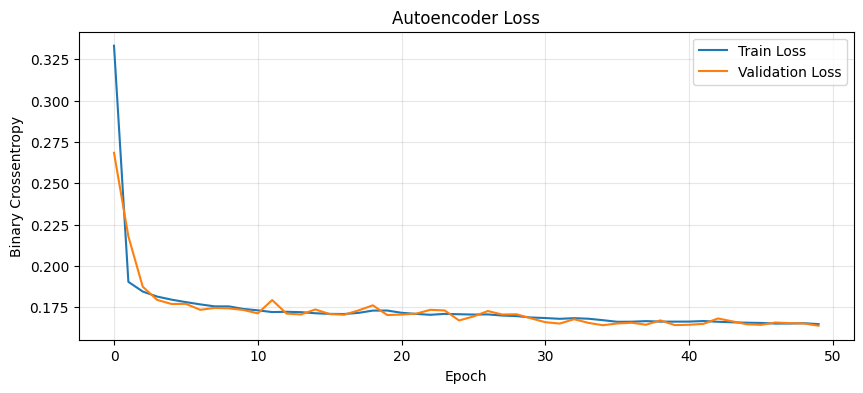

In [17]:
plt.figure(figsize=(10, 4))
plt.plot(history_ae.history['loss'], label='Train Loss')
plt.plot(history_ae.history['val_loss'], label='Validation Loss')
plt.title('Autoencoder Loss')
plt.xlabel('Epoch')
plt.ylabel('Binary Crossentropy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

---
## 4️) Rekonstrukcja obrazów testowych

Przepuszczamy obrazy testowe przez autoencoder i porównujemy je z oryginałami.


In [18]:
print("=== REKONSTRUKCJA OBRAZÓW TESTOWYCH ===")
x_test_reconstructed = autoencoder.predict(x_test_flat, verbose=0)

=== REKONSTRUKCJA OBRAZÓW TESTOWYCH ===


###  Wizualizacja: Oryginał vs Rekonstrukcja vs Różnica

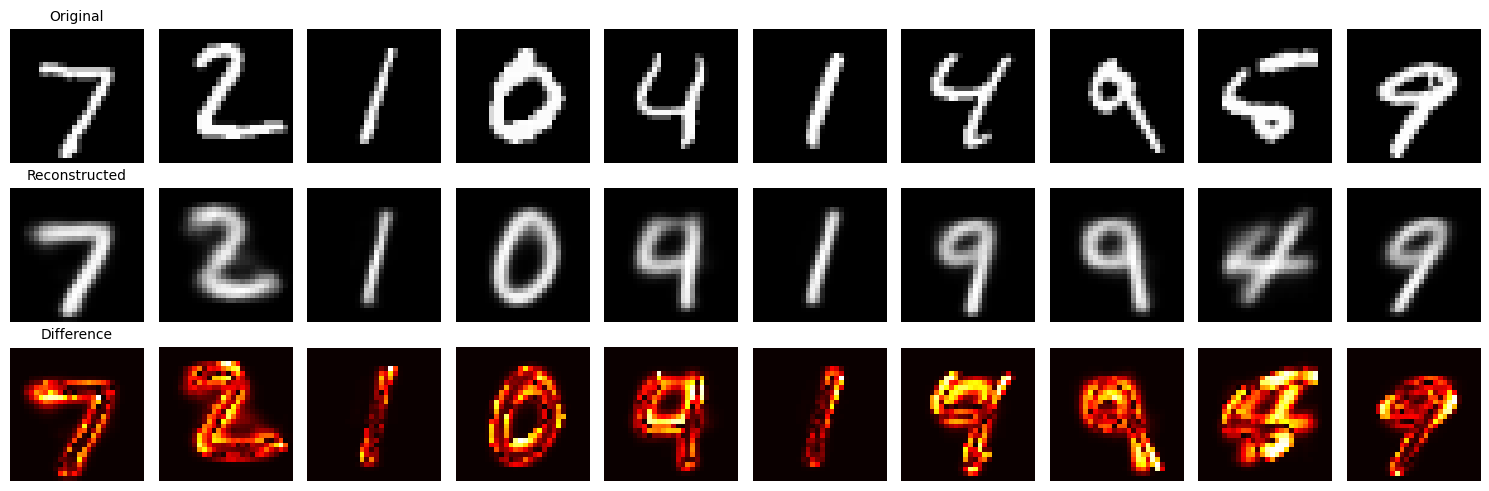

✅ Zapisano: reconstruction_comparison.png


In [19]:
fig, axes = plt.subplots(3, 10, figsize=(15, 5))

for i in range(10):
    # Oryginał
    axes[0, i].imshow(x_test[i], cmap='gray')
    axes[0, i].axis('off')
    if i == 0:
        axes[0, i].set_title('Original', fontsize=10)

    # Rekonstrukcja
    axes[1, i].imshow(x_test_reconstructed[i].reshape(28, 28), cmap='gray')
    axes[1, i].axis('off')
    if i == 0:
        axes[1, i].set_title('Reconstructed', fontsize=10)

    # Różnica
    diff = np.abs(x_test[i] - x_test_reconstructed[i].reshape(28, 28))
    axes[2, i].imshow(diff, cmap='hot')
    axes[2, i].axis('off')
    if i == 0:
        axes[2, i].set_title('Difference', fontsize=10)

plt.tight_layout()
plt.savefig('reconstruction_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Zapisano: reconstruction_comparison.png")

---
## 5️) Porównanie klasyfikacji: Oryginalne vs Zrekonstruowane

Testujemy klasyfikator (trenowany na oryginalnych obrazach) na obrazach zrekonstruowanych.


In [20]:
print("=== PORÓWNANIE KLASYFIKACJI ===")

# Predykcje
y_pred_original = np.argmax(classifier.predict(x_test_flat, verbose=0), axis=1)
y_pred_reconstructed = np.argmax(classifier.predict(x_test_reconstructed, verbose=0), axis=1)

# Dokładność na zrekonstruowanych
loss_recon, acc_recon = classifier.evaluate(x_test_reconstructed, y_test, verbose=0)

print(f"\nDokładność na ORYGINALNYCH obrazach:      {acc_orig:.4f}")
print(f"Dokładność na ZREKONSTRUOWANYCH obrazach: {acc_recon:.4f}")
print(f"Różnica (spadek):                          {acc_orig - acc_recon:.4f}")

=== PORÓWNANIE KLASYFIKACJI ===

Dokładność na ORYGINALNYCH obrazach:      0.9797
Dokładność na ZREKONSTRUOWANYCH obrazach: 0.8416
Różnica (spadek):                          0.1381


###  Macierze pomyłek (Confusion Matrices)

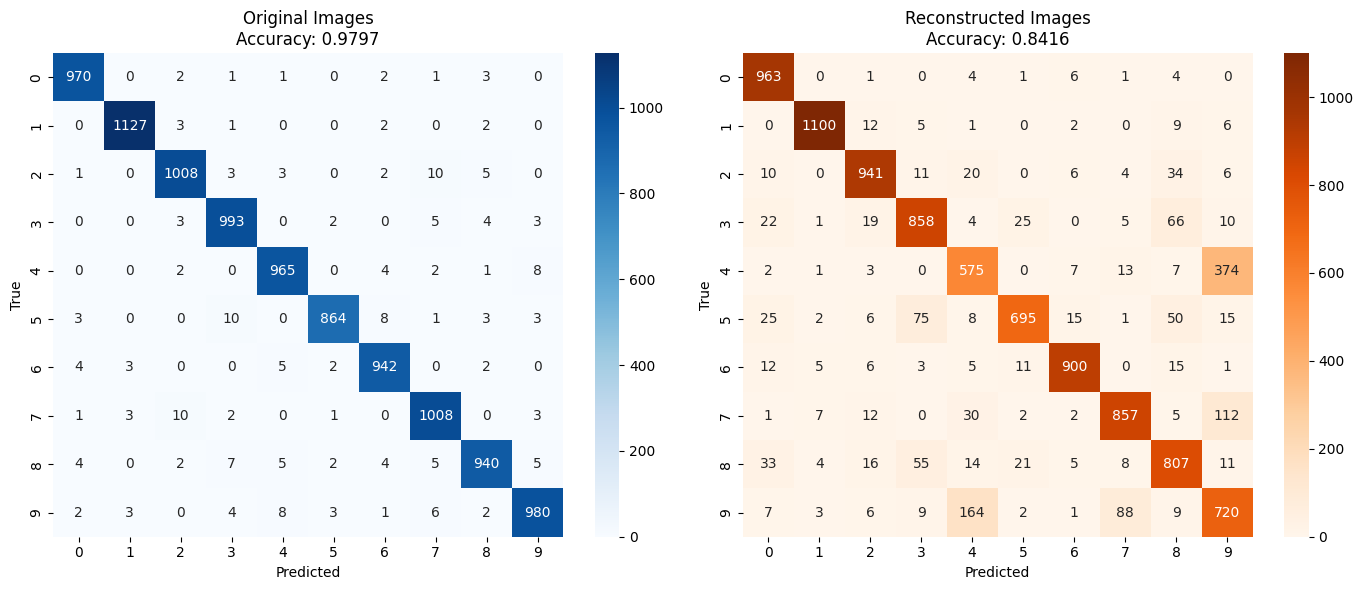

✅ Zapisano: classification_comparison.png


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Oryginalne obrazy
cm_orig = confusion_matrix(y_test, y_pred_original)
sns.heatmap(cm_orig, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title(f'Original Images\nAccuracy: {acc_orig:.4f}')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

# Zrekonstruowane obrazy
cm_recon = confusion_matrix(y_test, y_pred_reconstructed)
sns.heatmap(cm_recon, annot=True, fmt='d', cmap='Oranges', ax=axes[1])
axes[1].set_title(f'Reconstructed Images\nAccuracy: {acc_recon:.4f}')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

plt.tight_layout()
plt.savefig('classification_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Zapisano: classification_comparison.png")

---

## 6) Wizualizacja przestrzeni latentnej

Generujemy siatkę 20×20 punktów w przestrzeni latentnej (x,y) ∈ (-1,1) i pokazujemy, co dekoder generuje dla każdego punktu.


=== GENEROWANIE WIZUALIZACJI PRZESTRZENI LATENTNEJ ===


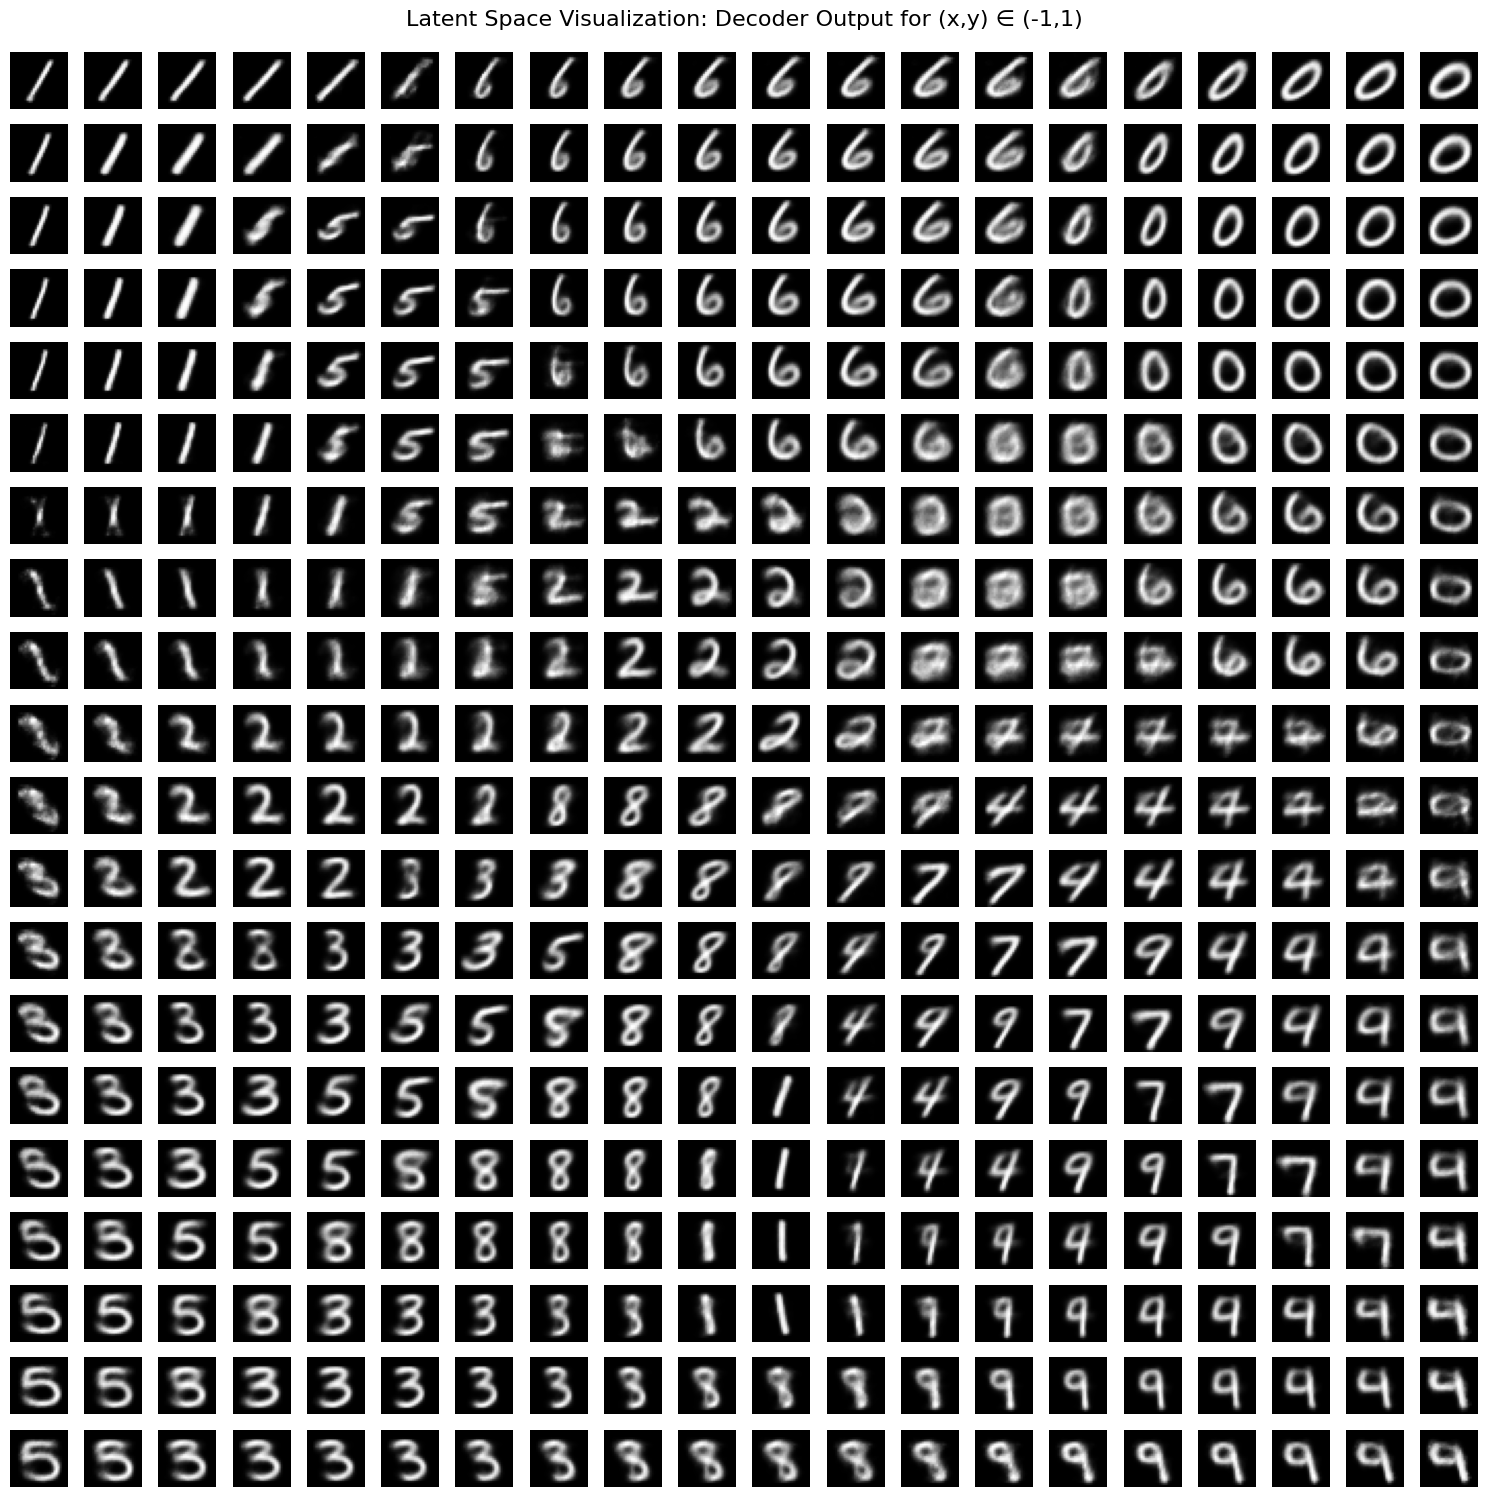

✅ Zapisano: latent_space_visualization.png


In [22]:
print("=== GENEROWANIE WIZUALIZACJI PRZESTRZENI LATENTNEJ ===")

# Siatka wartości od -0.95 do 0.95
n_points = 20
grid_x = np.linspace(-0.95, 0.95, n_points)
grid_y = np.linspace(-0.95, 0.95, n_points)

# Przygotowanie figury
fig, axes = plt.subplots(n_points, n_points, figsize=(15, 15))

for i, y in enumerate(grid_y):
    for j, x in enumerate(grid_x):
        # Generowanie obrazu z punktu (x, y)
        latent_point = np.array([[x, y]])
        generated_image = decoder.predict(latent_point, verbose=0)

        # Wyświetlenie
        axes[i, j].imshow(generated_image.reshape(28, 28), cmap='gray')
        axes[i, j].axis('off')

plt.suptitle('Latent Space Visualization: Decoder Output for (x,y) ∈ (-1,1)',
             fontsize=16, y=0.995)
plt.tight_layout()
plt.savefig('latent_space_visualization.png', dpi=200, bbox_inches='tight')
plt.show()
print(" Zapisano: latent_space_visualization.png")

---

## 7️) Rozkład cyfr w przestrzeni latentnej

Kodujemy obrazy testowe i pokazujemy, jak różne cyfry są rozmieszczone w 2D przestrzeni latentnej.

=== WIZUALIZACJA ROZKŁADU CYFR W PRZESTRZENI LATENTNEJ ===


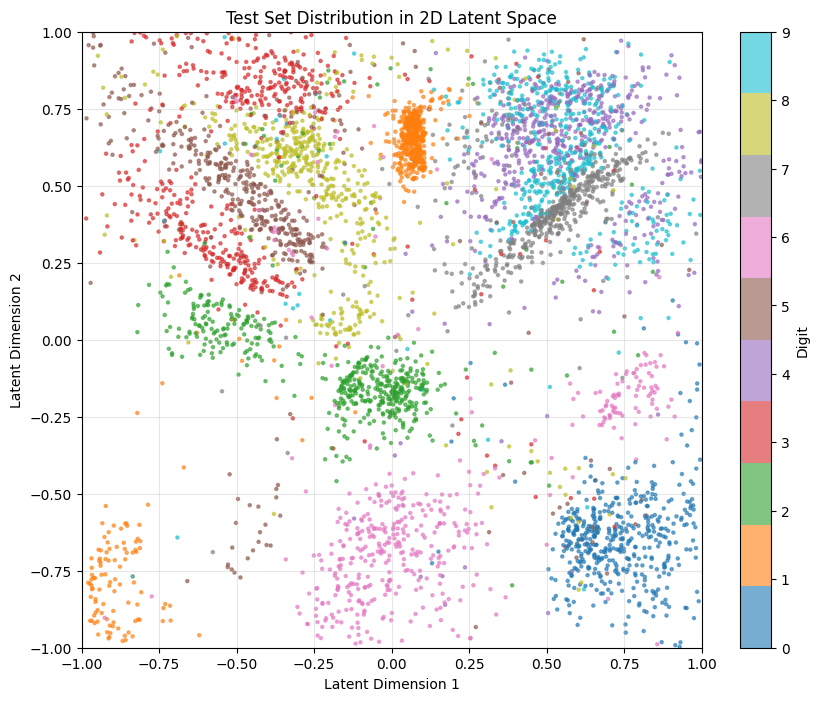

✅ Zapisano: latent_space_distribution.png


In [23]:
print("=== WIZUALIZACJA ROZKŁADU CYFR W PRZESTRZENI LATENTNEJ ===")

# Zakodowanie 5000 obrazów testowych
x_test_encoded = encoder.predict(x_test_flat[:5000], verbose=0)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    x_test_encoded[:, 0],
    x_test_encoded[:, 1],
    c=y_test[:5000],
    cmap='tab10',
    alpha=0.6,
    s=5
)
plt.colorbar(scatter, label='Digit')
plt.xlabel('Latent Dimension 1')
plt.ylabel('Latent Dimension 2')
plt.title('Test Set Distribution in 2D Latent Space')
plt.grid(True, alpha=0.3)
plt.xlim(-1, 1)
plt.ylim(-1, 1)
plt.savefig('latent_space_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Zapisano: latent_space_distribution.png")

---

##  Podsumowanie wyników

In [24]:
print("\n" + "="*50)
print("PODSUMOWANIE WYNIKÓW")
print("="*50)
print(f"1. Klasyfikator - dokładność na oryginalnych: {acc_orig:.4f}")
print(f"2. Klasyfikator - dokładność na zrekonstruowanych: {acc_recon:.4f}")
print(f"3. Spadek dokładności: {(acc_orig - acc_recon)*100:.2f}%")
print(f"\nWygenerowane pliki:")
print("   reconstruction_comparison.png")
print("   classification_comparison.png")
print("   latent_space_visualization.png")
print("   latent_space_distribution.png")
print("\n Zadanie zakończone!")


PODSUMOWANIE WYNIKÓW
1. Klasyfikator - dokładność na oryginalnych: 0.9797
2. Klasyfikator - dokładność na zrekonstruowanych: 0.8416
3. Spadek dokładności: 13.81%

Wygenerowane pliki:
  ✅ reconstruction_comparison.png
  ✅ classification_comparison.png
  ✅ latent_space_visualization.png
  ✅ latent_space_distribution.png

🎉 Zadanie zakończone!


---

##  Wnioski

1. **Kompresja 784D → 2D** powoduje znaczną utratę informacji
2. Zrekonstruowane obrazy są rozmyte, ale często rozpoznawalne
3. Klasyfikator ma **niższą dokładność** na zrekonstruowanych obrazach
4. Przestrzeń latentna pokazuje, jak autoencoder organizuje cyfry w 2D

###  Możliwe ulepszenia:
- Zwiększenie wymiarowości przestrzeni latentnej (np. do 10D lub 32D)
- Użycie konwolucyjnych warstw (CNN)
- Variational Autoencoder (VAE) dla lepszej przestrzeni latentnej
- Więcej epok treningu